# Telco Churn: Exploratory Charts
**Project:** Causal-indexed multimodal retrieval for churn explanation
**Author:** Jiya Virpara

This notebook is the first step of the data plan (README §6). It loads the Telco Customer Churn dataset and produces a few basic charts. Later, similar charts will be rendered from synthetic data so that chart-parsing accuracy can be measured against known values (RQ3).

**Sections**
1. Load and clean the data
2. Churn rate by contract type
3. Retention curves by contract type (Kaplan-Meier, implemented by hand)
4. Tenure and monthly charges vs. churn
5. Candidate causal drivers (support-related services)
6. Save figures

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
os.makedirs("figures", exist_ok=True)

## 1. Load and clean the data
The cell below downloads a public copy of the Telco dataset. If the download fails, get `WA_Fn-UseC_-Telco-Customer-Churn.csv` from Kaggle and upload it to Colab (Files panel on the left), then set `PATH` accordingly.

In [2]:
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"   # fallback if you upload the Kaggle file

try:
    df = pd.read_csv(URL)
except Exception as e:
    print("Download failed, trying local file:", e)
    df = pd.read_csv(PATH)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Cleaning: TotalCharges has blank strings for brand-new customers (tenure = 0)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Binary churn target
df["churn"] = (df["Churn"] == "Yes").astype(int)

print(f"Overall churn rate: {df['churn'].mean():.1%}")
df.describe(include="all").T.head(12)

Missing TotalCharges: 11
Overall churn rate: 26.5%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Churn rate by contract type
Month-to-month customers churn far more than customers on longer contracts. This is a correlation only; it says nothing yet about *why*.

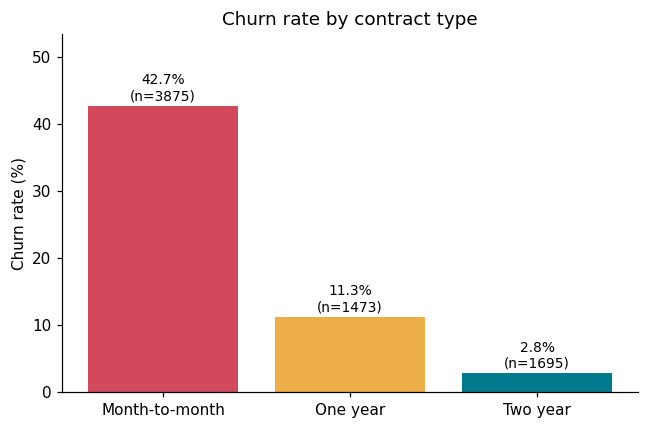

In [4]:
order = ["Month-to-month", "One year", "Two year"]
rate = df.groupby("Contract")["churn"].mean().reindex(order)
n = df.groupby("Contract").size().reindex(order)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(order, rate * 100, color=["#d1495b", "#edae49", "#00798c"])
for b, r, k in zip(bars, rate, n):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8, f"{r:.1%}\n(n={k})", ha="center", fontsize=9)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate by contract type")
ax.set_ylim(0, rate.max() * 100 * 1.25)
fig.tight_layout()
fig.savefig("figures/churn_by_contract.png")
plt.show()

## 3. Retention curves by contract type
A retention curve is the share of customers still active after *t* months. Because many customers have not churned yet (censored), a plain average is biased, so this uses the Kaplan-Meier estimator: at each month, survival is multiplied by (1 - churn events / customers still at risk).

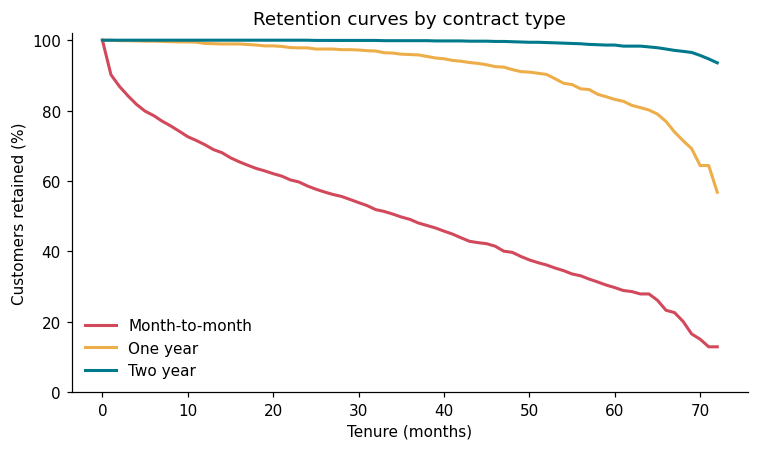

In [5]:
def kaplan_meier(tenure, event):
    """Return (months, survival) for durations `tenure` and event flags `event` (1 = churned)."""
    t = np.asarray(tenure); e = np.asarray(event)
    months = np.arange(0, t.max() + 1)
    surv, s = [], 1.0
    for m in months:
        at_risk = (t >= m).sum()
        events = ((t == m) & (e == 1)).sum()
        if at_risk > 0 and m > 0:
            s *= 1 - events / at_risk
        surv.append(s)
    return months, np.array(surv)

fig, ax = plt.subplots(figsize=(7, 4.2))
colors = {"Month-to-month": "#d1495b", "One year": "#edae49", "Two year": "#00798c"}
for c in order:
    sub = df[df["Contract"] == c]
    m, s = kaplan_meier(sub["tenure"], sub["churn"])
    ax.plot(m, s * 100, label=c, color=colors[c], lw=2)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Customers retained (%)")
ax.set_title("Retention curves by contract type")
ax.set_ylim(0, 102)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("figures/retention_by_contract.png")
plt.show()

## 4. Tenure and monthly charges vs. churn

/tmp/ipykernel_1086/2284709450.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=["Retained", "Churned"], patch_artist=True,


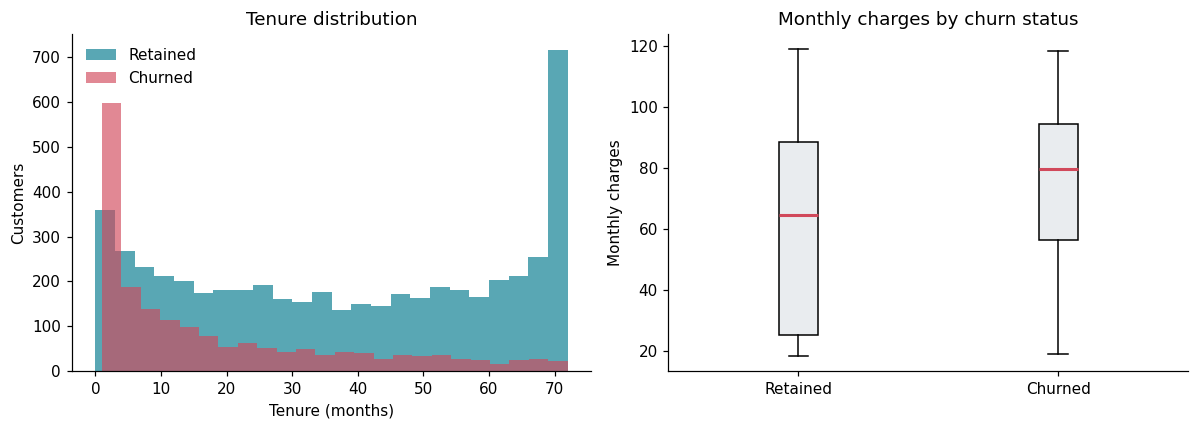

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Tenure distribution
for label, color in [(0, "#00798c"), (1, "#d1495b")]:
    axes[0].hist(df.loc[df["churn"] == label, "tenure"], bins=24, alpha=0.65,
                 color=color, label="Churned" if label else "Retained")
axes[0].set_xlabel("Tenure (months)"); axes[0].set_ylabel("Customers")
axes[0].set_title("Tenure distribution"); axes[0].legend(frameon=False)

# Monthly charges boxplot
data = [df.loc[df["churn"] == 0, "MonthlyCharges"], df.loc[df["churn"] == 1, "MonthlyCharges"]]
axes[1].boxplot(data, labels=["Retained", "Churned"], patch_artist=True,
                boxprops=dict(facecolor="#e9ecef"), medianprops=dict(color="#d1495b", lw=2))
axes[1].set_ylabel("Monthly charges")
axes[1].set_title("Monthly charges by churn status")

fig.tight_layout()
fig.savefig("figures/tenure_charges_vs_churn.png")
plt.show()

## 5. Candidate causal drivers
The Telco data has no support-ticket response time, but it has service flags that act as rough proxies for the kind of nodes the causal graph will contain (for example tech support). These are only *candidate* nodes; whether any of them **causes** churn is what Stage B of the project will test.

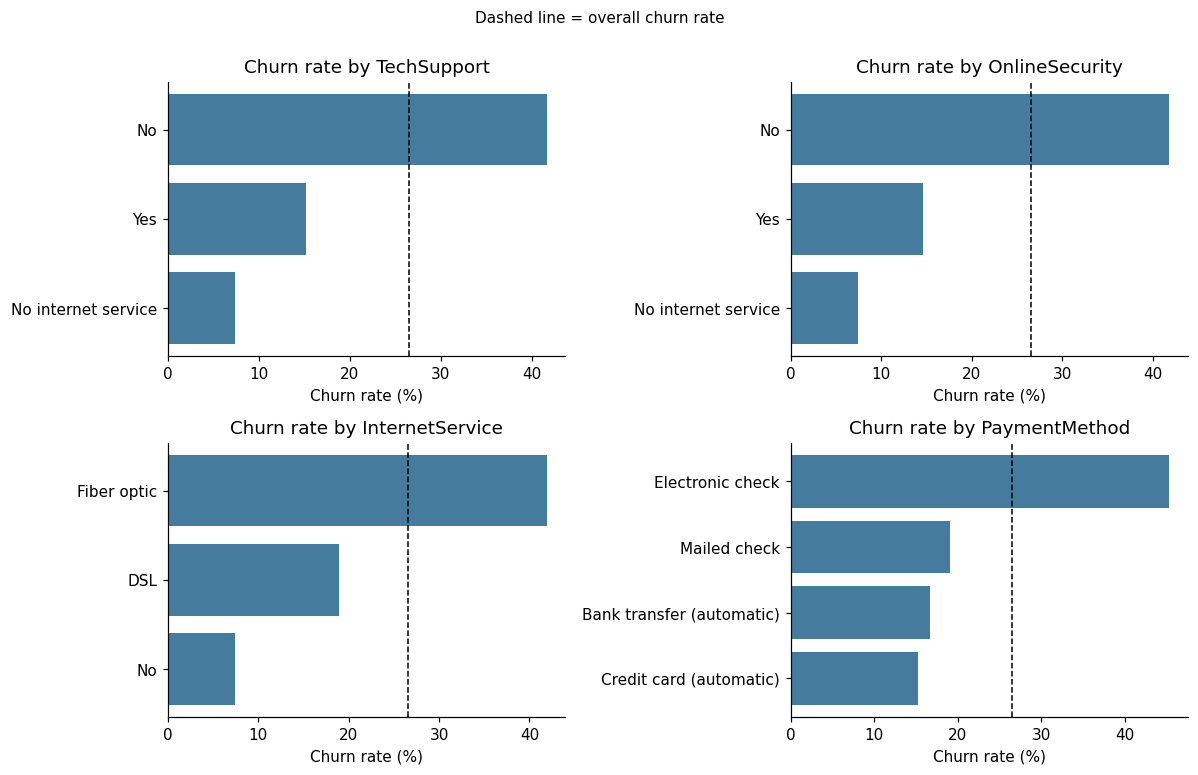

In [7]:
cols = ["TechSupport", "OnlineSecurity", "InternetService", "PaymentMethod"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, col in zip(axes.ravel(), cols):
    r = df.groupby(col)["churn"].mean().sort_values(ascending=False)
    ax.barh(r.index, r.values * 100, color="#457b9d")
    ax.invert_yaxis()
    ax.set_xlabel("Churn rate (%)")
    ax.set_title(f"Churn rate by {col}")
    ax.axvline(df["churn"].mean() * 100, color="k", ls="--", lw=1)  # overall rate

fig.suptitle("Dashed line = overall churn rate", y=1.0, fontsize=10)
fig.tight_layout()
fig.savefig("figures/churn_by_service_features.png")
plt.show()

### Correlation among numeric features
A quick look at associations. Strong correlation between tenure and total charges is expected (total charges is roughly tenure times monthly charges), which is a reminder of why correlation alone is a weak basis for recommendations.

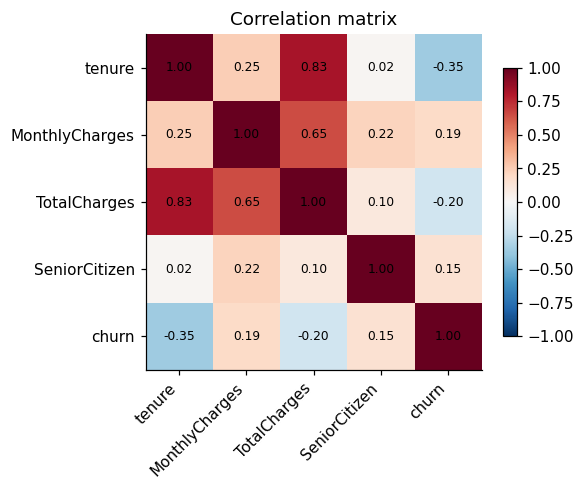

In [8]:
num = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "churn"]]
corr = num.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation matrix")
fig.tight_layout()
fig.savefig("figures/correlation_matrix.png")
plt.show()